In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

OUTPUT_PATH = "../outputs"

#### Load KPI tables

In [2]:
hr_kpi = pd.read_csv(f"{OUTPUT_PATH}/hr_kpi_table.csv")
absence_kpi = pd.read_csv(f"{OUTPUT_PATH}/absence_kpi_table.csv")
training_kpi = pd.read_csv(f"{OUTPUT_PATH}/training_kpi_table.csv")

#### KPI Distributions

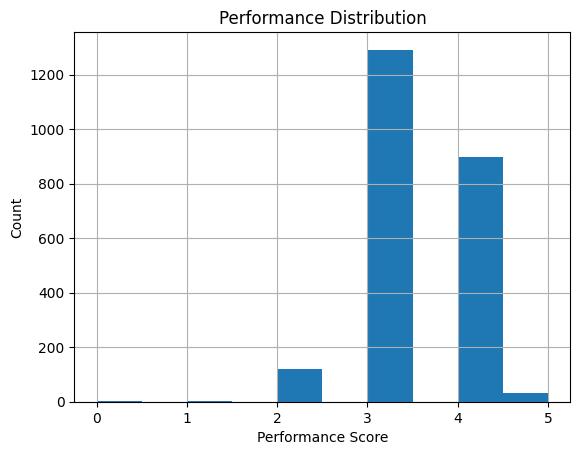

In [3]:
plt.figure()
hr_kpi["avg_performance"].hist()
plt.title("Performance Distribution")
plt.xlabel("Performance Score")
plt.ylabel("Count")
plt.show()

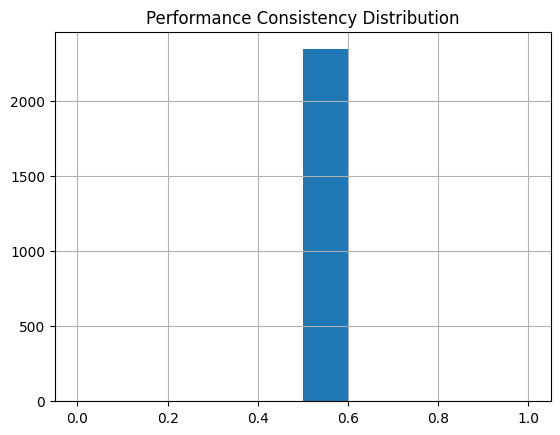

In [4]:
plt.figure()
hr_kpi["performance_consistency_score"].hist()
plt.title("Performance Consistency Distribution")
plt.show()

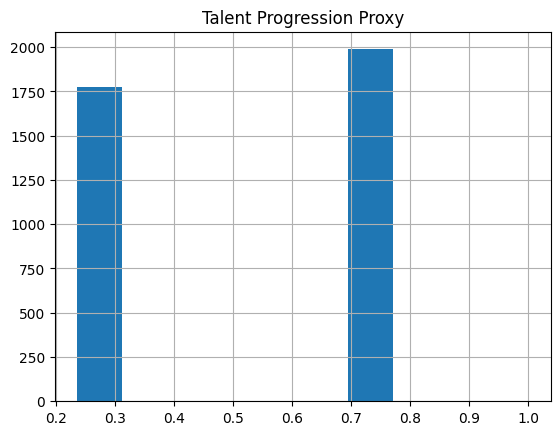

In [5]:
plt.figure()
hr_kpi["talent_progression_proxy"].hist()
plt.title("Talent Progression Proxy")
plt.show()

#### Correlations

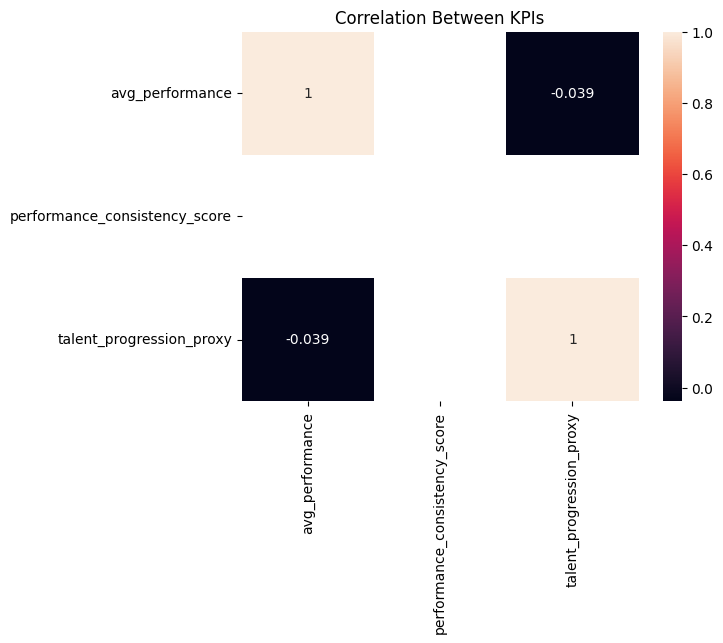

In [6]:
kpi_cols = [
    "avg_performance",
    "performance_consistency_score",
    "talent_progression_proxy"
]

corr = hr_kpi[kpi_cols].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Between KPIs")
plt.show()

#### Team Analysis

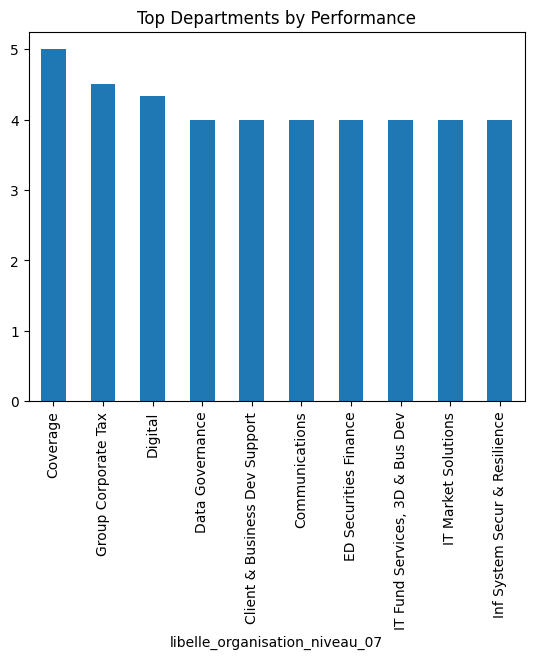

In [7]:
dept_perf = (
    hr_kpi
    .groupby("libelle_organisation_niveau_07")["avg_performance"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure()
dept_perf.plot(kind="bar")
plt.title("Top Departments by Performance")
plt.show()

#### Absenteeism vs Learning

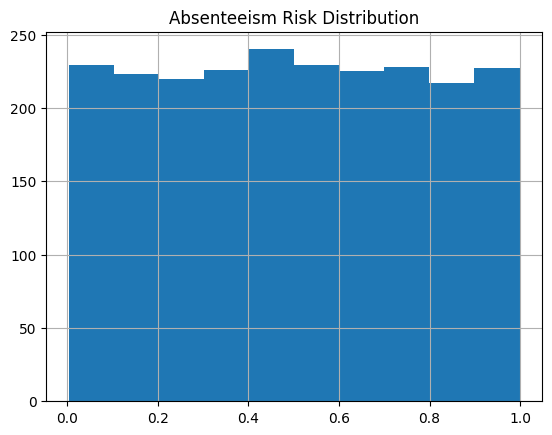

In [8]:
plt.figure()
absence_kpi["absenteeism_risk_score"].hist()
plt.title("Absenteeism Risk Distribution")
plt.show()

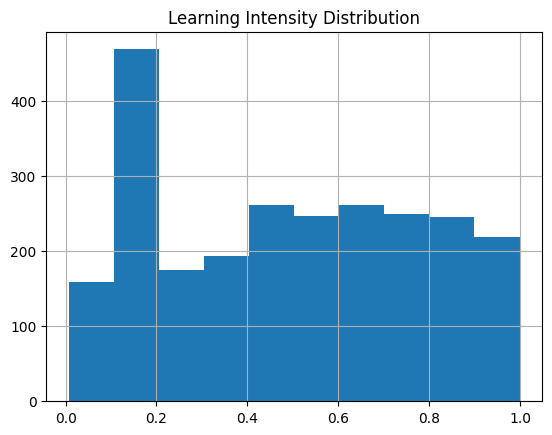

In [9]:
plt.figure()
training_kpi["learning_intensity_score"].hist()
plt.title("Learning Intensity Distribution")
plt.show()

 #### KEY INSIGHTS

**Insight 1 — Performance variability is limited** 

Most employees show high consistency, often due to limited evaluation data.

Interpretation: Performance metrics may lack granularity and should be complemented.

**Insight 2 — Talent progression is uneven** 

Some employees show significantly higher progression proxies.

Interpretation: Career growth is not evenly distributed.

**Insight 3 — Absenteeism and learning are highly dispersed**

Both KPIs show strong variability.

Interpretation: Employee engagement and development differ widely across the organization.